# INFOGRAPHICVQA: Regularized Sparse SAM2/DINOv2 Learned Graph

Автономный end-to-end эксперимент без импортов из проектных `src/` и `scripts/`.

- OCR и SAM2/DINOv2 создают узлы, но не готовые рёбра.
- Первый attention-слой строит структуру изображения без вопроса.
- Второй слой уточняет top-8 learned-связей с учётом вопроса.
- Node dropout, label smoothing, hub/sparsity penalties и multi-positive objective ограничивают переобучение.
- Validation выполняется после каждой эпохи; test запускается один раз по лучшему checkpoint.

In [1]:
from collections import Counter
import cv2
import os
from pathlib import Path
from contextlib import nullcontext
import json
import math
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image, ImageDraw
from sentence_transformers import SentenceTransformer
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader, Dataset, Sampler
from tqdm.auto import tqdm
from transformers import AutoImageProcessor, AutoModel
from ultralytics import SAM

DATASET = "infographicvqa"
SEED = 42
SMOKE = os.environ.get("NOTEBOOK_SMOKE") == "1"
EPOCHS = 1 if SMOKE else 20
MAX_CANDIDATES = 16 if SMOKE else 64
BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
MAX_OCR_NODES = 80
MAX_SAM_NODES = 32
HIDDEN_DIM = 192
NUM_HEADS = 4
NUM_LAYERS = 2
TOP_K_VISUAL_EDGES = 8
RUN_NATIVE_SAM_PREVIEW = True
PRECOMPUTE_NODE_FEATURES = True
FORCE_RETRAIN = False

# --- Fast visual-cache settings ---
# Главный ускоритель: если старые SAM2 boxes уже есть, используем их как prompts,
# вместо дорогого segment-everything с плотной сеткой точек.
PREFER_CACHED_SAM_BOXES = True
SAM_IMGSZ = 768
SAM_USE_HALF = True

# Fallback, если box-cache для изображения отсутствует.
# Строим собственную 12x12 сетку положительных point-prompts через публичный SAM API.
# Это обходит несовместимые с новым get_cfg внутренние kwargs points_stride/crop_n_layers.
SAM_AUTO_POINTS_STRIDE = 12

# Duplicate filtering выполняется на маленькой mask-grid, а не на full-resolution masks.
SAM_FILTER_GRID = 96
MAX_SAM_FILTER_CANDIDATES = 192

DINO_MODEL_NAME = "facebook/dinov2-base"
DINO_SHORT_EDGE = 518
DINO_USE_AMP = True
MIN_SAM_AREA_RATIO = 1e-4
MAX_SAM_AREA_RATIO = 0.65
DUPLICATE_MASK_IOU = 0.85

# Новый schema id не смешивает старые медленные/другие признаки с новой fast-cache версией.
FEATURE_SCHEMA_VERSION = "sam2_dinov2_sparse_regularized_v1"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Для frozen SAM2/DINO cache важнее throughput; Graph Transformer не использует conv-heavy kernels.
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_CUDA_AMP = DEVICE.type == "cuda"
print("device:", DEVICE)
if DEVICE.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print("gpu:", torch.cuda.get_device_name(0))
    print(f"vram: {props.total_memory / 1024**3:.1f} GB")
print("SAM cached-box prompts:", PREFER_CACHED_SAM_BOXES)
print("SAM fallback points/side:", SAM_AUTO_POINTS_STRIDE)
# --- Regularized learned-graph settings ---
LEARNED_TOP_K = 8
ATTENTION_DROPOUT = 0.25
INPUT_DROPOUT = 0.15
QUESTION_DROPOUT = 0.20
OCR_NODE_DROPOUT = 0.08
SAM_NODE_DROPOUT = 0.20
QUESTION_GRAPH_SCALE = 0.30
LABEL_SMOOTHING = 0.05
WEIGHT_DECAY = 1e-2
SPARSITY_COEFFICIENT = 0.002
HUB_COEFFICIENT = 0.01
MULTIPOSITIVE_WEIGHT = 0.50
VQA_WEIGHT = 0.50
EARLY_STOPPING_PATIENCE = 5

device: cuda
gpu: NVIDIA GeForce RTX 4060 Laptop GPU
vram: 8.0 GB
SAM cached-box prompts: True
SAM fallback points/side: 12


### Compatibility fix for recent Ultralytics

- SAM FP16 prediction uses `quantize=16` instead of deprecated `half=True`.
- The no-box fallback uses an explicit point grid through the public `points=` API instead of passing internal `generate()` kwargs through `Model.predict()`.


## Пути и формат AI2D

Ноутбук не импортирует код из `src/` или `scripts/`. Все функции эксперимента определены ниже.

In [2]:
def find_project_root() -> Path:
    start = Path.cwd().resolve()
    bases = (start, *start.parents)
    candidates = [candidate for base in bases for candidate in (base, base / "diagram_vqa")]
    for candidate in candidates:
        if (candidate / "notebooks" / "experiments").exists() and (candidate / "runs").exists():
            return candidate
    raise FileNotFoundError("Не найден корень diagram_vqa")


PROJECT_ROOT = find_project_root()
DATA_ROOT = PROJECT_ROOT.parent
MANIFEST_PATH = DATA_ROOT / "infographicvqa/prepared_v1/manifest.jsonl"
OCR_ROOT = DATA_ROOT / "model_matrix_cache/ocr/infographicvqa"
SAM_CHECKPOINT = DATA_ROOT / "models" / "sam2" / "sam2.1_b.pt"
SAM_BOX_CACHE = DATA_ROOT / "model_matrix_cache/sam2_boxes/infographicvqa"
RUN_DIR = PROJECT_ROOT / "runs" / "infographicvqa" / "sam2_dinov2_regularized_sparse_learned_graph" / ("seed42_smoke" if SMOKE else "seed42_full")
FEATURE_CACHE = DATA_ROOT / "model_matrix_cache/sam2_dinov2_features/infographicvqa" / f"node_features_{FEATURE_SCHEMA_VERSION}"
RUN_DIR.mkdir(parents=True, exist_ok=True)
FEATURE_CACHE.mkdir(parents=True, exist_ok=True)

print("project:", PROJECT_ROOT)
print("manifest:", MANIFEST_PATH)
print("run:", RUN_DIR)
print("feature cache:", FEATURE_CACHE)


project: C:\Users\Jet\Desktop\data\diagram_vqa
manifest: C:\Users\Jet\Desktop\data\infographicvqa\prepared_v1\manifest.jsonl
run: C:\Users\Jet\Desktop\data\diagram_vqa\runs\infographicvqa\sam2_dinov2_regularized_sparse_learned_graph\seed42_full
feature cache: C:\Users\Jet\Desktop\data\model_matrix_cache\sam2_dinov2_features\infographicvqa\node_features_sam2_dinov2_sparse_regularized_v1


In [3]:
def load_manifest(path: Path) -> list[dict]:
    rows = []
    for line in path.read_text(encoding="utf-8").splitlines():
        if not line.strip():
            continue
        row = json.loads(line)
        image_path = Path(row["image_path"])
        if not image_path.is_absolute():
            image_path = DATA_ROOT / image_path
        row["image_path"] = str(image_path.resolve())
        row["image_id"] = str(row.get("image_id", row.get("doc_id", image_path.stem)))
        row["sample_id"] = str(row.get("sample_id", row.get("question_id", len(rows))))
        row["answers"] = [str(value) for value in row.get("answers", [])]
        rows.append(row)
    return rows


rows = load_manifest(MANIFEST_PATH)
train_rows = [row for row in rows if row["split"] == "train"]
val_rows = [row for row in rows if row["split"] == "val"]
test_rows = [row for row in rows if row["split"] == "test"]
if SMOKE:
    train_rows, val_rows, test_rows = train_rows[:8], val_rows[:4], test_rows[:4]

format_table = pd.DataFrame([
    {"split": split, "questions": len(values), "images": len({row["image_id"] for row in values}),
      "fields": "image, OCR, question, open answer"}
    for split, values in (("train", train_rows), ("val", val_rows), ("test", test_rows))
])
display(format_table)
display(pd.DataFrame(train_rows[:3])[["image_id", "question", "answers"]])


,split,questions,images,fields
0,train,23946,4406,"image, OCR, question, open answer"
1,val,2801,500,"image, OCR, question, open answer"
2,test,3288,579,"image, OCR, question, open answer"


,image_id,question,answers
0,20471,Which type of fonts offer better readability i...,[serif fonts]
1,20471,Which fonts are suited for the web?,"[sans serif, sans serif fonts]"
2,20471,Which medium has the highest resolution?,[print]


## OCR и SAM2

OCR даёт текст и bounding box. SAM2 даёт **маски визуальных регионов**, а не только прямоугольники.
Маски затем используются для masked pooling DINOv2-признаков. Пространственный KNN и заранее заданные рёбра не используются.


{'image_id': '20471', 'question': 'Which type of fonts offer better readability in printed works?', 'answers': ['serif fonts']}


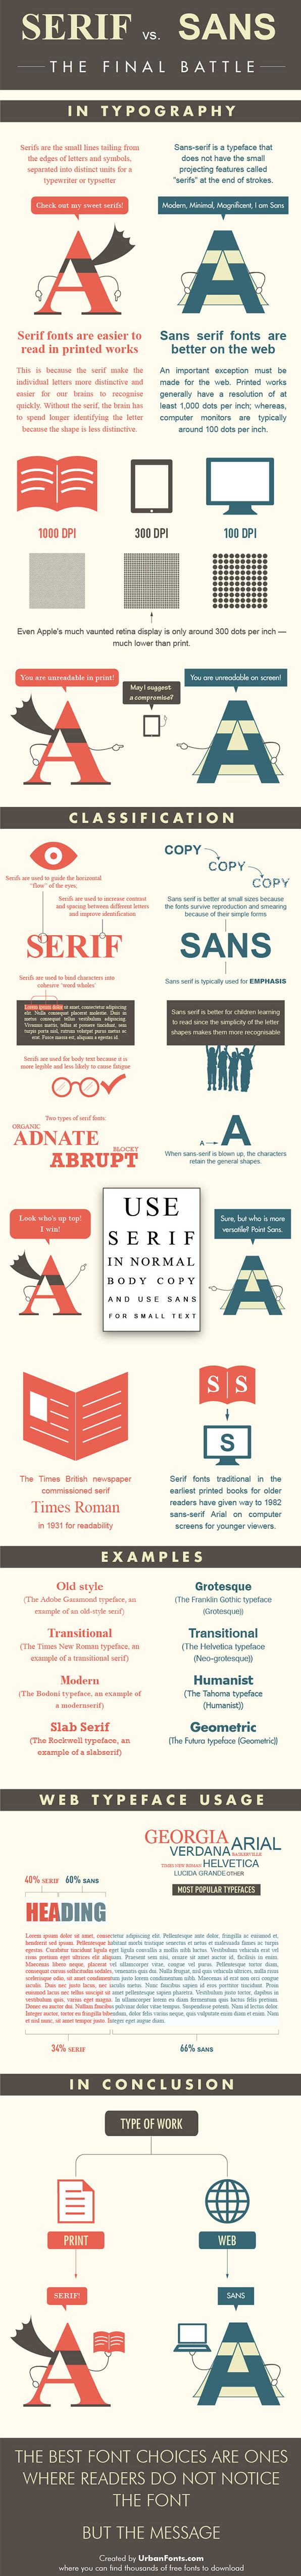

In [4]:
def _bbox_from_polygon(values):
    xs = [float(values[index]) for index in range(0, len(values), 2)]
    ys = [float(values[index]) for index in range(1, len(values), 2)]
    return [min(xs), min(ys), max(xs), max(ys)] if xs and ys else [0.0, 0.0, 0.0, 0.0]


def load_ocr_words(row: dict) -> list[dict]:
    if DATASET == "docvqa":
        path = Path(str(row.get("ocr_path", "")))
        if not path.exists():
            return []
        payload = json.loads(path.read_text(encoding="utf-8"))
        pages = payload.get("recognitionResults") or payload.get("analyzeResult", {}).get("readResults") or []
        words = []
        for page in pages:
            for line in page.get("lines", []):
                polygon = line.get("boundingBox") or line.get("polygon") or []
                words.append({"text": str(line.get("text", "")).strip(), "bbox": _bbox_from_polygon(polygon), "kind": "ocr"})
        return [word for word in words if word["text"]][:MAX_OCR_NODES]

    cache_path = OCR_ROOT / f"{row['image_id']}.json"
    if cache_path.exists():
        return json.loads(cache_path.read_text(encoding="utf-8"))[:MAX_OCR_NODES]
    import pytesseract
    windows_tesseract = Path("C:/Program Files/Tesseract-OCR/tesseract.exe")
    if windows_tesseract.exists():
        pytesseract.pytesseract.tesseract_cmd = str(windows_tesseract)
    image = Image.open(row["image_path"]).convert("RGB")
    data = pytesseract.image_to_data(image, output_type=pytesseract.Output.DICT, config="--psm 11")
    words = []
    for index, text in enumerate(data.get("text", [])):
        value = str(text).strip()
        if not value:
            continue
        x, y = int(data["left"][index]), int(data["top"][index])
        width, height = int(data["width"][index]), int(data["height"][index])
        words.append({"text": value, "bbox": [x, y, x + width, y + height], "kind": "ocr"})
    OCR_ROOT.mkdir(parents=True, exist_ok=True)
    cache_path.write_text(json.dumps(words, ensure_ascii=False), encoding="utf-8")
    return words[:MAX_OCR_NODES]

_sam_model = None
_last_sam_regions = None


def sam_model():
    global _sam_model
    if _sam_model is None:
        _sam_model = SAM(str(SAM_CHECKPOINT))
    return _sam_model


def release_sam_model():
    global _sam_model, _last_sam_regions
    _last_sam_regions = None
    if _sam_model is not None:
        try:
            _sam_model.model.to("cpu")
        except Exception:
            pass
        _sam_model = None
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def _cached_sam_boxes(row: dict) -> list[list[float]]:
    cache_path = SAM_BOX_CACHE / f"{row['image_id']}.json"
    if cache_path.exists():
        try:
            boxes = json.loads(cache_path.read_text(encoding="utf-8"))
            return [list(map(float, box[:4])) for box in boxes[:MAX_SAM_NODES] if len(box) >= 4]
        except Exception:
            pass
    image = cv2.imread(str(row["image_path"]), cv2.IMREAD_GRAYSCALE)
    if image is None:
        return []
    height, width = image.shape[:2]
    if image.ndim == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if image.shape[2] >= 3 else image[..., 0]
    blurred = cv2.GaussianBlur(image, (5, 5), 0)
    edges = cv2.Canny(blurred, 60, 160)
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    proposals = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        area_ratio = (w * h) / max(1, width * height)
        if 0.0002 <= area_ratio <= 0.65 and w >= 8 and h >= 8:
            proposals.append([float(x), float(y), float(x + w), float(y + h)])
    proposals.sort(key=lambda box: (box[2] - box[0]) * (box[3] - box[1]), reverse=True)
    proposals = proposals[:MAX_SAM_NODES] or [[0.0, 0.0, float(width), float(height)]]
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    cache_path.write_text(json.dumps(proposals), encoding="utf-8")
    return proposals


def _save_sam_boxes(row: dict, boxes: torch.Tensor):
    cache_path = SAM_BOX_CACHE / f"{row['image_id']}.json"
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    cache_path.write_text(json.dumps(boxes.detach().cpu().tolist()), encoding="utf-8")


def _masks_in_original_coordinates(result) -> torch.Tensor:
    """Keep SAM masks on their native grid; DINO pooling resizes selected masks later."""
    if result.masks is None:
        return torch.empty((0, 1, 1), dtype=torch.bool, device=DEVICE)
    masks = result.masks.data.detach()
    if masks.ndim == 2:
        masks = masks[None]
    return masks.to(device="cpu", non_blocking=False) > 0.5


@torch.inference_mode()
def filter_sam_regions(boxes: torch.Tensor, masks: torch.Tensor, scores: torch.Tensor | None = None):
    """Area + near-duplicate filtering on a tiny grid, keeping full masks only for selected regions."""
    if len(boxes) == 0 or len(masks) == 0:
        return boxes[:0].detach().cpu().float(), masks[:0]

    count = min(len(boxes), len(masks))
    device = masks.device
    boxes = boxes[:count].to(device=device, dtype=torch.float32)
    masks = masks[:count]

    # A 96x96 grid is enough for area/duplicate tests and avoids O(N^2 * H * W) CPU work.
    small = F.interpolate(
        masks[:, None].to(dtype=torch.float32),
        size=(SAM_FILTER_GRID, SAM_FILTER_GRID),
        mode="nearest",
    )[:, 0]
    area_ratio = small.mean(dim=(1, 2))
    valid = torch.where((area_ratio >= MIN_SAM_AREA_RATIO) & (area_ratio <= MAX_SAM_AREA_RATIO))[0]
    if len(valid) == 0:
        return boxes[:0].detach().cpu(), masks[:0]

    if scores is not None and len(scores) >= count:
        score_values = scores[:count].to(device=device, dtype=torch.float32)
        valid = valid[torch.argsort(score_values[valid], descending=True)]

    # Prevent pathological automatic-mask outputs from making pairwise IoU expensive.
    valid = valid[:MAX_SAM_FILTER_CANDIDATES]
    small_valid = small[valid].flatten(1)
    areas = small_valid.sum(dim=1)
    intersections = small_valid @ small_valid.T
    unions = areas[:, None] + areas[None, :] - intersections
    iou = intersections / unions.clamp_min(1.0)

    kept_local = []
    suppressed = torch.zeros(len(valid), dtype=torch.bool, device=device)
    for local_index in range(len(valid)):
        if bool(suppressed[local_index]):
            continue
        kept_local.append(local_index)
        suppressed |= iou[local_index] >= DUPLICATE_MASK_IOU
        if len(kept_local) >= MAX_SAM_NODES:
            break

    selected = valid[torch.tensor(kept_local, dtype=torch.long, device=device)]
    return boxes[selected].detach().cpu().float(), masks[selected]


@torch.inference_mode()
def run_sam_regions(
    row: dict,
    image: Image.Image | None = None,
    reuse_last: bool = False,
    keep_result: bool = False,
    force_auto: bool = False,
):
    global _last_sam_regions
    image_id = str(row["image_id"])
    if reuse_last and _last_sam_regions is not None and _last_sam_regions["image_id"] == image_id:
        if not keep_result or _last_sam_regions.get("result") is not None:
            return _last_sam_regions

    # Release previous preview payload before a new full SAM result is allocated.
    if _last_sam_regions is not None and _last_sam_regions.get("image_id") != image_id:
        _last_sam_regions = None

    if image is None:
        image = Image.open(row["image_path"]).convert("RGB")

    cached_boxes = [] if force_auto or not PREFER_CACHED_SAM_BOXES else _cached_sam_boxes(row)
    common_kwargs = {
        "imgsz": SAM_IMGSZ,
        "device": str(DEVICE),
        "verbose": False,
    }
    # Ultralytics 2026+: half=True is deprecated in favor of quantize=16.
    # Omit quantize entirely on CPU so older/non-CUDA paths stay FP32.
    if SAM_USE_HALF and DEVICE.type == "cuda":
        common_kwargs["quantize"] = 16

    if cached_boxes:
        # Fast path: one image encoder pass + mask decoding only for the <=64 known regions.
        result = sam_model()(image, bboxes=cached_boxes, **common_kwargs)[0]
        sam_mode = "cached_box_prompts"
    else:
        # Public-API-safe fallback. Do NOT pass points_stride/crop_n_layers to Model.predict():
        # recent Ultralytics versions validate them through get_cfg and reject these internal generate() kwargs.
        # Instead, create a uniform grid of independent positive point prompts in original-image coordinates.
        n_side = int(SAM_AUTO_POINTS_STRIDE)
        xs = (np.arange(n_side, dtype=np.float32) + 0.5) * (image.width / n_side)
        ys = (np.arange(n_side, dtype=np.float32) + 0.5) * (image.height / n_side)
        grid_x, grid_y = np.meshgrid(xs, ys)
        point_prompts = np.stack([grid_x.ravel(), grid_y.ravel()], axis=1).tolist()
        point_labels = [1] * len(point_prompts)
        result = sam_model()(
            image,
            points=point_prompts,
            labels=point_labels,
            **common_kwargs,
        )[0]
        sam_mode = "manual_point_grid_fallback"

    if result.boxes is None or result.masks is None:
        h, w = image.height, image.width
        boxes = torch.empty((0, 4), dtype=torch.float32)
        masks = torch.empty((0, h, w), dtype=torch.bool, device=DEVICE)
    else:
        masks = _masks_in_original_coordinates(result)
        boxes_device = result.boxes.xyxy.detach().to(masks.device, dtype=torch.float32)
        scores = (
            result.boxes.conf.detach().to(masks.device)
            if getattr(result.boxes, "conf", None) is not None
            else None
        )
        boxes, masks = filter_sam_regions(boxes_device, masks, scores)

    # If there was no prior box cache, keep the filtered regions for all future runs.
    if not cached_boxes and len(boxes):
        _save_sam_boxes(row, boxes)

    payload = {
        "image_id": image_id,
        "boxes": boxes,
        "masks": masks,
        "sam_mode": sam_mode,
        "result": result if keep_result else None,
    }
    if reuse_last:
        _last_sam_regions = payload
    return payload


def load_or_run_sam_boxes(row: dict, force_native: bool = False) -> tuple[list[list[float]], object | None]:
    cached = _cached_sam_boxes(row)
    if cached and not force_native:
        return cached, None

    image = Image.open(row["image_path"]).convert("RGB")
    regions = run_sam_regions(row, image=image, reuse_last=True, keep_result=True, force_auto=False)
    boxes = regions["boxes"].tolist()
    if boxes:
        _save_sam_boxes(row, regions["boxes"])
    return boxes, regions["result"]


sample = max(train_rows[:500], key=lambda row: len(load_ocr_words(row)))
image = Image.open(sample["image_path"]).convert("RGB")
print({key: sample.get(key) for key in ("image_id", "question", "answers")})
display(image)


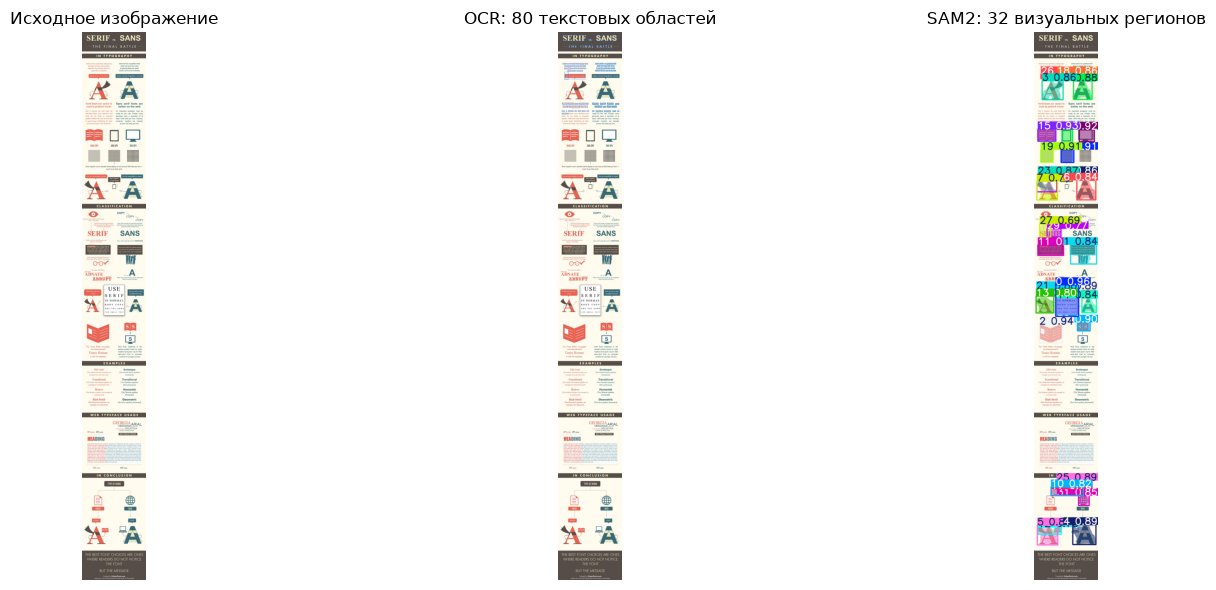

In [5]:
def draw_processing(row: dict, run_native_sam: bool = True):
    image = Image.open(row["image_path"]).convert("RGB")
    ocr_words = load_ocr_words(row)
    ocr_view = image.copy()
    draw = ImageDraw.Draw(ocr_view)
    for word in ocr_words:
        draw.rectangle(word["bbox"], outline=(0, 120, 255), width=2)

    boxes, native_result = load_or_run_sam_boxes(row, force_native=run_native_sam)
    if native_result is not None:
        sam_view = Image.fromarray(native_result.plot()[..., ::-1])
    else:
        sam_view = image.copy()
        draw_sam = ImageDraw.Draw(sam_view)
        for box in boxes:
            draw_sam.rectangle(box, outline=(255, 128, 0), width=2)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(image); axes[0].set_title("Исходное изображение")
    axes[1].imshow(ocr_view); axes[1].set_title(f"OCR: {len(ocr_words)} текстовых областей")
    axes[2].imshow(sam_view); axes[2].set_title(f"SAM2: {len(boxes)} визуальных регионов")
    for axis in axes:
        axis.axis("off")
    plt.tight_layout()
    plt.show()
    return ocr_words, boxes


preview_ocr, preview_sam = draw_processing(sample, run_native_sam=RUN_NATIVE_SAM_PREVIEW)

## Признаки узлов: OCR + fast SAM2 masks + DINOv2

Для OCR: `384-d MiniLM embedding`, дополненный нулями до 768-d, + 9 геометрических признаков + `type=1`.

Для SAM2: **768-d DINOv2 embedding региона**, полученный masked pooling по patch-токенам внутри SAM2-маски,
+ 9 геометрических признаков + `type=0`.

Ускоренный cache-path сначала читает уже существующие `sam2_boxes` и подаёт до 64 bbox как prompts в SAM2.
Это избегает дорогого `segment everything` для большинства изображений. Если bbox-cache отсутствует, используется fallback
с разреженной автоматической grid. Нативные `result.masks.data` используются напрямую — polygon→PIL rasterization удалён.
DINOv2 и masked pooling выполняются на GPU; на CPU переносится только итоговый embedding каждого региона.


In [6]:
from tqdm import tqdm
TEXT_DIM = 384
VISUAL_DIM = 768
GEOMETRY_DIM = 10
NODE_DIM = VISUAL_DIM + GEOMETRY_DIM


text_encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device="cpu")
_dino_processor = None
_dino_model = None
CACHE_TIMING = {"images": 0, "ocr": 0.0, "sam": 0.0, "dino": 0.0, "save": 0.0, "prompted": 0, "fallback": 0}


def dino_encoder():
    global _dino_processor, _dino_model
    if _dino_processor is None:
        _dino_processor = AutoImageProcessor.from_pretrained(DINO_MODEL_NAME)
    if _dino_model is None:
        _dino_model = AutoModel.from_pretrained(DINO_MODEL_NAME).to(DEVICE).eval()
        _dino_model.requires_grad_(False)
        actual_dim = int(_dino_model.config.hidden_size)
        if actual_dim != VISUAL_DIM:
            raise ValueError(f"Ожидался DINOv2 hidden_size={VISUAL_DIM}, получено {actual_dim}")
    return _dino_processor, _dino_model


def release_dino_encoder():
    global _dino_model
    if _dino_model is not None:
        _dino_model.to("cpu")
        _dino_model = None
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def geometry_features(box, width: int, height: int, node_type: float) -> torch.Tensor:
    x1, y1, x2, y2 = map(float, box)
    w = max(1.0, x2 - x1)
    h = max(1.0, y2 - y1)
    return torch.tensor([
        (x1 + x2) / (2 * width), (y1 + y2) / (2 * height),
        w / width, h / height, (w * h) / (width * height),
        x1 / width, y1 / height, x2 / width, y2 / height, node_type,
    ], dtype=torch.float32)


def _dino_amp_context():
    if DEVICE.type == "cuda" and DINO_USE_AMP:
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()


@torch.inference_mode()
def dino_patch_grid(image: Image.Image) -> torch.Tensor:
    """Return patch grid on DEVICE; do not round-trip a ~1M-element tensor through CPU."""
    processor, encoder = dino_encoder()
    inputs = processor(
        images=image,
        return_tensors="pt",
        do_center_crop=False,
        size={"shortest_edge": DINO_SHORT_EDGE},
    )
    pixel_values = inputs["pixel_values"].to(DEVICE, non_blocking=True)
    with _dino_amp_context():
        outputs = encoder(pixel_values=pixel_values)
        patch_tokens = outputs.last_hidden_state[:, 1:, :]

    patch_size = int(encoder.config.patch_size)
    grid_h = int(pixel_values.shape[-2] // patch_size)
    grid_w = int(pixel_values.shape[-1] // patch_size)
    expected = grid_h * grid_w
    if patch_tokens.shape[1] != expected:
        raise RuntimeError(
            f"DINO patch-grid mismatch: tokens={patch_tokens.shape[1]}, grid={grid_h}x{grid_w}={expected}"
        )
    return patch_tokens[0].reshape(grid_h, grid_w, VISUAL_DIM)


@torch.inference_mode()
def masked_dino_pool(
    patch_grid: torch.Tensor,
    masks: torch.Tensor,
    boxes: torch.Tensor,
    image_width: int,
    image_height: int,
) -> torch.Tensor:
    """Masked pooling entirely on GPU; only final Nx768 vectors are copied to CPU."""
    if len(masks) == 0:
        return torch.empty((0, VISUAL_DIM), dtype=torch.float32)

    # Pool the small selected mask set on CPU to avoid VRAM spikes and CUDA GEMM failures.
    patch_grid = patch_grid.detach().float().cpu()
    grid_h, grid_w, _ = patch_grid.shape
    pool_dtype = patch_grid.dtype
    masks_device = masks.to(device=patch_grid.device)
    weights = F.interpolate(
        masks_device[:, None].to(dtype=pool_dtype),
        size=(grid_h, grid_w),
        mode="bilinear",
        align_corners=False,
    )[:, 0].clamp_(0.0, 1.0)

    flat_features = patch_grid.reshape(-1, VISUAL_DIM)
    flat_weights = weights.reshape(len(masks_device), -1)
    denominators = flat_weights.sum(dim=1, keepdim=True)
    pooled = (flat_weights @ flat_features) / denominators.clamp_min(1e-6)

    # Tiny masks can disappear on a coarse DINO patch-grid; use bbox pooling only for those few cases.
    missing = torch.where(denominators[:, 0] < 1e-4)[0].detach().cpu().tolist()
    for index in missing:
        x1, y1, x2, y2 = boxes[index].tolist()
        gx1 = max(0, min(grid_w - 1, int(math.floor(x1 / image_width * grid_w))))
        gy1 = max(0, min(grid_h - 1, int(math.floor(y1 / image_height * grid_h))))
        gx2 = max(gx1 + 1, min(grid_w, int(math.ceil(x2 / image_width * grid_w))))
        gy2 = max(gy1 + 1, min(grid_h, int(math.ceil(y2 / image_height * grid_h))))
        pooled[index] = patch_grid[gy1:gy2, gx1:gx2].reshape(-1, VISUAL_DIM).mean(dim=0)

    return F.normalize(pooled.float(), dim=-1).cpu()


def build_node_features(row: dict) -> dict:
    cache_path = FEATURE_CACHE / f"{row['image_id']}.pt"
    if cache_path.exists():
        payload = torch.load(cache_path, map_location="cpu", weights_only=False)
        if payload.get("schema_version") == FEATURE_SCHEMA_VERSION and payload["x"].shape[-1] == NODE_DIM:
            return payload

    image = Image.open(row["image_path"]).convert("RGB")
    width, height = image.size

    t0 = time.perf_counter()
    # OCR semantic nodes.
    ocr_words = load_ocr_words(row)
    texts = [word["text"] for word in ocr_words]
    text_vectors = (
        torch.from_numpy(text_encoder.encode(texts, normalize_embeddings=True, show_progress_bar=False)).float()
        if texts else torch.empty((0, TEXT_DIM), dtype=torch.float32)
    )
    features = []
    for index, word in enumerate(ocr_words):
        semantic = torch.zeros(VISUAL_DIM, dtype=torch.float32)
        semantic[:TEXT_DIM] = text_vectors[index]
        features.append(torch.cat([semantic, geometry_features(word["bbox"], width, height, 1.0)]))
    t1 = time.perf_counter()

    # SAM2: cached bbox prompts first; automatic grid only if the box cache is missing.
    regions = run_sam_regions(row, image=image, reuse_last=False, keep_result=False)
    sam_boxes = regions["boxes"][:MAX_SAM_NODES]
    sam_masks = regions["masks"][:MAX_SAM_NODES]
    t2 = time.perf_counter()

    if len(sam_boxes):
        patch_grid = dino_patch_grid(image)
        visual_vectors = masked_dino_pool(patch_grid, sam_masks, sam_boxes, width, height)
        for box, vector in zip(sam_boxes, visual_vectors):
            features.append(torch.cat([vector, geometry_features(box, width, height, 0.0)]))
        del patch_grid, sam_masks
    t3 = time.perf_counter()

    if not features:
        features = [torch.zeros(NODE_DIM, dtype=torch.float32)]

    payload = {
        "x": torch.stack(features).float(),
        "schema_version": FEATURE_SCHEMA_VERSION,
        "source": "OCR MiniLM + filtered SAM2 masks + DINOv2 pooling; sparse graph learned later",
        "ocr_nodes": len(ocr_words),
        "ocr_texts": texts,
        "sam_nodes": int(len(sam_boxes)),
        "sam_mode": regions["sam_mode"],
    }
    torch.save(payload, cache_path)
    t4 = time.perf_counter()

    CACHE_TIMING["images"] += 1
    CACHE_TIMING["ocr"] += t1 - t0
    CACHE_TIMING["sam"] += t2 - t1
    CACHE_TIMING["dino"] += t3 - t2
    CACHE_TIMING["save"] += t4 - t3
    if regions["sam_mode"] == "cached_box_prompts":
        CACHE_TIMING["prompted"] += 1
    else:
        CACHE_TIMING["fallback"] += 1

    return payload


preview_features = build_node_features(sample)
print("node tensor:", tuple(preview_features["x"].shape))
print("source:", preview_features["source"])
print("OCR nodes:", preview_features["ocr_nodes"], "SAM+DINO nodes:", preview_features["sam_nodes"])
print("SAM mode:", preview_features.get("sam_mode"))
print("edge_index: отсутствует")


if PRECOMPUTE_NODE_FEATURES:
    unique_rows = {}
    for row in (*train_rows, *val_rows, *test_rows):
        unique_rows.setdefault(row["image_id"], row)

    box_cache_hits = sum((SAM_BOX_CACHE / f"{row['image_id']}.json").exists() for row in unique_rows.values())
    print(f"existing SAM box-cache: {box_cache_hits}/{len(unique_rows)} images")
    if box_cache_hits:
        print("fast path: cached boxes -> SAM2 prompts -> masks -> one DINOv2 pass")
    print(f"fallback manual point-grid: {SAM_AUTO_POINTS_STRIDE}x{SAM_AUTO_POINTS_STRIDE} prompts (only when boxes are missing)")

    progress = tqdm(unique_rows.values(), desc="Fast SAM2 + DINOv2 feature cache")
    for index, row in enumerate(progress, start=1):
        build_node_features(row)
        n = CACHE_TIMING["images"]
        if n and (index <= 10 or index % 10 == 0):
            progress.set_postfix({
                "sam_s": f"{CACHE_TIMING['sam']/n:.2f}",
                "dino_s": f"{CACHE_TIMING['dino']/n:.2f}",
                "ocr_s": f"{CACHE_TIMING['ocr']/n:.2f}",
                "box%": f"{100*CACHE_TIMING['prompted']/n:.0f}",
            })

    release_dino_encoder()
    release_sam_model()
    print(f"cached images: {len(unique_rows)}")
    if CACHE_TIMING["images"]:
        n = CACHE_TIMING["images"]
        print(
            "average uncached image: "
            f"SAM={CACHE_TIMING['sam']/n:.2f}s, "
            f"DINO+pool={CACHE_TIMING['dino']/n:.2f}s, "
            f"OCR={CACHE_TIMING['ocr']/n:.2f}s, "
            f"save={CACHE_TIMING['save']/n:.2f}s"
        )
        print(f"SAM fast-box prompts: {CACHE_TIMING['prompted']}, fallback auto-grid: {CACHE_TIMING['fallback']}")


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.48, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


node tensor: (112, 778)
source: OCR MiniLM + filtered SAM2 masks + DINOv2 pooling; sparse graph learned later
OCR nodes: 80 SAM+DINO nodes: 32
SAM mode: cached_box_prompts
edge_index: отсутствует
existing SAM box-cache: 1/5485 images
fast path: cached boxes -> SAM2 prompts -> masks -> one DINOv2 pass
fallback manual point-grid: 12x12 prompts (only when boxes are missing)


Fast SAM2 + DINOv2 feature cache:   0%|          | 0/5485 [00:00<?, ?it/s]

Fast SAM2 + DINOv2 feature cache:   0%|          | 0/5485 [00:00<?, ?it/s, sam_s=0.25, dino_s=1.88, ocr_s=0.06, box%=100]

Fast SAM2 + DINOv2 feature cache:   0%|          | 0/5485 [00:01<?, ?it/s, sam_s=0.67, dino_s=1.28, ocr_s=0.05, box%=100]

...

Fast SAM2 + DINOv2 feature cache: 100%|█████████▉| 5483/5485 [55:46<00:01,  1.60it/s, sam_s=0.30, dino_s=0.23, ocr_s=0.06, box%=100]

Fast SAM2 + DINOv2 feature cache: 100%|█████████▉| 5484/5485 [55:46<00:00,  1.57it/s, sam_s=0.30, dino_s=0.23, ocr_s=0.06, box%=100]

Fast SAM2 + DINOv2 feature cache: 100%|██████████| 5485/5485 [55:48<00:00,  1.15it/s, sam_s=0.30, dino_s=0.23, ocr_s=0.06, box%=100]

Fast SAM2 + DINOv2 feature cache: 100%|██████████| 5485/5485 [55:48<00:00,  1.64it/s, sam_s=0.30, dino_s=0.23, ocr_s=0.06, box%=100]

cached images: 5485
average uncached image: SAM=0.30s, DINO+pool=0.23s, OCR=0.06s, save=0.00s
SAM fast-box prompts: 5485, fallback auto-grid: 0


## Разреженный граф, обучаемый моделью

Для каждой пары регионов вычисляется learned score:

`sᵢⱼ = qᵢ·kⱼ / √d + MLP(Δx, Δy, |Δx|, |Δy|, distance)`

После этого сохраняются top-8 связей по learned score. Это не KNN: координаты являются только одним из
обучаемых признаков, а выбор соседей зависит от текста, изображения и вопроса.

In [7]:
class SparseLearnedGraphAttention(nn.Module):
    def __init__(self, hidden: int, heads: int, top_k: int = LEARNED_TOP_K, dropout: float = ATTENTION_DROPOUT):
        super().__init__()
        assert hidden % heads == 0
        self.heads = heads
        self.head_dim = hidden // heads
        self.top_k = top_k
        self.qkv = nn.Linear(hidden, hidden * 3)
        self.spatial_bias = nn.Sequential(nn.Linear(5, 32), nn.GELU(), nn.Linear(32, heads))
        self.output = nn.Linear(hidden, hidden)
        self.norm1 = nn.LayerNorm(hidden)
        self.ffn = nn.Sequential(
            nn.Linear(hidden, hidden * 4), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(hidden * 4, hidden),
        )
        self.norm2 = nn.LayerNorm(hidden)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, centers, mask):
        batch_size, nodes, hidden = x.shape
        qkv = self.qkv(x).view(batch_size, nodes, 3, self.heads, self.head_dim)
        q, k, v = qkv.unbind(dim=2)
        q, k, v = [value.transpose(1, 2) for value in (q, k, v)]
        logits = torch.matmul(q, k.transpose(-1, -2)) / math.sqrt(self.head_dim)

        delta = centers[:, :, None, :] - centers[:, None, :, :]
        pair_geometry = torch.cat([delta, delta.abs(), torch.linalg.vector_norm(delta, dim=-1, keepdim=True)], dim=-1)
        logits = logits + self.spatial_bias(pair_geometry).permute(0, 3, 1, 2)

        valid_pairs = mask[:, None, :, None] & mask[:, None, None, :]
        logits = logits.masked_fill(~valid_pairs, -1e4)
        k_eff = min(self.top_k, nodes)
        top_indices = logits.topk(k_eff, dim=-1).indices
        sparse_mask = torch.zeros_like(valid_pairs.expand(-1, self.heads, -1, -1))
        sparse_mask.scatter_(-1, top_indices, True)
        sparse_mask &= valid_pairs
        sparse_logits = logits.masked_fill(~sparse_mask, -1e4)
        attention = torch.softmax(sparse_logits, dim=-1) * sparse_mask
        attention = attention / attention.sum(dim=-1, keepdim=True).clamp_min(1e-8)

        context = torch.matmul(self.dropout(attention), v)
        context = context.transpose(1, 2).reshape(batch_size, nodes, hidden)
        x = self.norm1(x + self.dropout(self.output(context)))
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x, attention


class RegularizedSparseSamDinoGraph(nn.Module):
    def __init__(self, text_dim=TEXT_DIM, visual_dim=VISUAL_DIM, hidden=HIDDEN_DIM, heads=NUM_HEADS):
        super().__init__()
        self.ocr_input = nn.Sequential(nn.Linear(text_dim + GEOMETRY_DIM, hidden), nn.GELU(), nn.LayerNorm(hidden))
        self.sam_input = nn.Sequential(nn.Linear(visual_dim + GEOMETRY_DIM, hidden), nn.GELU(), nn.LayerNorm(hidden))
        self.question = nn.Sequential(nn.Linear(text_dim, hidden), nn.GELU(), nn.Dropout(QUESTION_DROPOUT), nn.Linear(hidden, hidden))
        self.candidate = nn.Sequential(nn.Linear(text_dim, hidden), nn.GELU(), nn.Linear(hidden, hidden))
        self.input_dropout = nn.Dropout(INPUT_DROPOUT)
        self.image_layer = SparseLearnedGraphAttention(hidden, heads)
        self.question_layer = SparseLearnedGraphAttention(hidden, heads)
        self.document_gate = nn.Linear(hidden, 1)
        self.question_gate = nn.Linear(hidden, 1)
        self.hybrid = nn.Sequential(
            nn.Linear(hidden * 2, hidden), nn.GELU(), nn.Dropout(ATTENTION_DROPOUT), nn.Linear(hidden, hidden)
        )

    def project_nodes(self, nodes):
        semantic = nodes[..., :VISUAL_DIM]
        geometry = nodes[..., VISUAL_DIM:VISUAL_DIM + GEOMETRY_DIM]
        is_ocr = geometry[..., -1] > 0.5
        ocr_hidden = self.ocr_input(torch.cat([semantic[..., :TEXT_DIM], geometry], dim=-1))
        sam_hidden = self.sam_input(torch.cat([semantic, geometry], dim=-1))
        return self.input_dropout(torch.where(is_ocr[..., None], ocr_hidden, sam_hidden)), is_ocr

    def regularized_mask(self, mask, is_ocr):
        if not self.training:
            return mask
        probabilities = torch.where(
            is_ocr,
            torch.full_like(is_ocr, OCR_NODE_DROPOUT, dtype=torch.float32),
            torch.full_like(is_ocr, SAM_NODE_DROPOUT, dtype=torch.float32),
        )
        keep = torch.rand_like(probabilities) >= probabilities
        result = mask & keep
        # Preserve one real node per sample even in pathological tiny graphs.
        for index in range(result.shape[0]):
            if not result[index].any():
                result[index, torch.where(mask[index])[0][0]] = True
        return result

    @staticmethod
    def pool(x, mask, gate):
        logits = gate(torch.tanh(x)).squeeze(-1).masked_fill(~mask, -1e4)
        return torch.sum(torch.softmax(logits, dim=1)[..., None] * x, dim=1)

    def forward(self, nodes, mask, question_embeddings, candidate_embeddings, candidate_mask=None, return_attention=False):
        x, is_ocr = self.project_nodes(nodes)
        active_mask = self.regularized_mask(mask, is_ocr)
        centers = nodes[..., VISUAL_DIM:VISUAL_DIM + 2]

        # Stable image graph before seeing the question.
        image_nodes, image_attention = self.image_layer(x, centers, active_mask)
        documents = F.normalize(self.pool(image_nodes, active_mask, self.document_gate), dim=-1)

        questions = F.normalize(self.question(question_embeddings), dim=-1)
        conditioned = image_nodes + QUESTION_GRAPH_SCALE * questions[:, None, :]
        question_nodes, question_attention = self.question_layer(conditioned, centers, active_mask)
        question_graph = F.normalize(self.pool(question_nodes, active_mask, self.question_gate), dim=-1)
        context = F.normalize(self.hybrid(torch.cat([question_graph, questions], dim=-1)), dim=-1)

        candidates = F.normalize(self.candidate(candidate_embeddings), dim=-1)
        vqa_logits = torch.einsum("bd,bcd->bc", context, candidates)
        if candidate_mask is not None:
            vqa_logits = vqa_logits.masked_fill(~candidate_mask, -1e4)
        retrieval_logits = questions @ documents.T
        return {
            "vqa_logits": vqa_logits,
            "retrieval_logits": retrieval_logits,
            "documents": documents,
            "questions": questions,
            "active_mask": active_mask,
            "attention": torch.stack([image_attention, question_attention]),
        }


model = RegularizedSparseSamDinoGraph().to(DEVICE)
trainable_parameters = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
print(model)
print(f"trainable parameters: {trainable_parameters:,}")
print("predefined edges: 0")
print(f"learned edge budget: top-{LEARNED_TOP_K} per node/head")

RegularizedSparseSamDinoGraph(
  (ocr_input): Sequential(
    (0): Linear(in_features=394, out_features=192, bias=True)
    (1): GELU(approximate='none')
    (2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  )
  (sam_input): Sequential(
    (0): Linear(in_features=778, out_features=192, bias=True)
    (1): GELU(approximate='none')
    (2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  )
  (question): Sequential(
    (0): Linear(in_features=384, out_features=192, bias=True)
    (1): GELU(approximate='none')
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=192, out_features=192, bias=True)
  )
  (candidate): Sequential(
    (0): Linear(in_features=384, out_features=192, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=192, out_features=192, bias=True)
  )
  (input_dropout): Dropout(p=0.15, inplace=False)
  (image_layer): SparseLearnedGraphAttention(
    (qkv): Linear(in_features=192, out_features=576, bias=True)
    (spatial_

## Multi-positive batching

Вопросы одной диаграммы остаются положительными парами для retrieval loss. Padding поддерживает AI2D-вопросы
с разным количеством вариантов ответа.

In [8]:
class DocumentQuestions(Dataset):
    def __init__(self, values): self.values = values
    def __len__(self): return len(self.values)
    def __getitem__(self, index): return self.values[index]


class MultiPositiveBatchSampler(Sampler):
    def __init__(self, values, batch_size, seed=SEED):
        self.batch_size, self.seed, self.epoch = batch_size, seed, 0
        groups = {}
        for index, row in enumerate(values):
            groups.setdefault(row["image_id"], []).append(index)
        self.groups = list(groups.values())

    def __iter__(self):
        rng = random.Random(self.seed + self.epoch)
        groups = self.groups.copy(); rng.shuffle(groups); self.epoch += 1
        batch = []
        for group in groups:
            if batch and len(batch) + len(group) > self.batch_size:
                yield batch; batch = []
            batch.extend(group)
        if batch: yield batch

    def __len__(self):
        return math.ceil(sum(map(len, self.groups)) / self.batch_size)


text_embedding_cache = {}


def encode_texts(values):
    values = [str(value) for value in values]
    missing = list(dict.fromkeys(value for value in values if value not in text_embedding_cache))
    if missing:
        vectors = text_encoder.encode(missing, normalize_embeddings=True, batch_size=128, show_progress_bar=False)
        text_embedding_cache.update({text: torch.from_numpy(vector).float() for text, vector in zip(missing, vectors)})
    return torch.stack([text_embedding_cache[value] for value in values])


def normalize_answer(value):
    return " ".join(str(value).strip().lower().split())


def levenshtein(left, right):
    if len(left) < len(right): left, right = right, left
    previous = list(range(len(right) + 1))
    for i, char_left in enumerate(left, 1):
        current = [i]
        for j, char_right in enumerate(right, 1):
            current.append(min(current[-1] + 1, previous[j] + 1, previous[j - 1] + (char_left != char_right)))
        previous = current
    return previous[-1]


def anls(prediction, answers, threshold=0.5):
    prediction = normalize_answer(prediction)
    scores = []
    for answer in answers:
        gold = normalize_answer(answer)
        similarity = 1.0 - levenshtein(prediction, gold) / max(1, len(prediction), len(gold))
        scores.append(similarity if similarity >= threshold else 0.0)
    return max(scores, default=0.0)


def token_f1(prediction, answers):
    predicted = normalize_answer(prediction).split()
    best = 0.0
    for answer in answers:
        gold = normalize_answer(answer).split()
        common = sum((Counter(predicted) & Counter(gold)).values())
        if common:
            precision, recall = common / len(predicted), common / len(gold)
            best = max(best, 2 * precision * recall / (precision + recall))
    return best


def candidate_values(row):
    words = [word["text"] for word in load_ocr_words(row) if str(word.get("text", "")).strip()]
    values = []
    for value in words:
        if value not in values: values.append(value)
    for size in (2, 3, 4, 5, 6):
        for start in range(max(0, len(words) - size + 1)):
            value = " ".join(words[start:start + size])
            if value not in values: values.append(value)
            if len(values) >= MAX_CANDIDATES: return values
    return values[:MAX_CANDIDATES] or [""]


def collate_questions(batch_rows):
    feature_rows = [build_node_features(row)["x"] for row in batch_rows]
    max_nodes = max(value.shape[0] for value in feature_rows)
    nodes = torch.zeros((len(batch_rows), max_nodes, NODE_DIM))
    mask = torch.zeros((len(batch_rows), max_nodes), dtype=torch.bool)
    for index, value in enumerate(feature_rows):
        nodes[index, :len(value)] = value; mask[index, :len(value)] = True
    questions = encode_texts([row["question"] for row in batch_rows])
    candidate_text_rows = [candidate_values(row) for row in batch_rows]
    candidate_rows = [encode_texts(values) for values in candidate_text_rows]
    max_candidates = max(len(value) for value in candidate_rows)
    candidates = torch.zeros((len(batch_rows), max_candidates, TEXT_DIM))
    candidate_mask = torch.zeros((len(batch_rows), max_candidates), dtype=torch.bool)
    targets = []
    for index, (values, embeddings, row) in enumerate(zip(candidate_text_rows, candidate_rows, batch_rows)):
        candidates[index, :len(embeddings)] = embeddings; candidate_mask[index, :len(embeddings)] = True
        scores = [anls(value, row.get("answers", [])) for value in values]
        targets.append(int(np.argmax(scores)) if scores else 0)
    return {
        "rows": batch_rows, "image_ids": [row["image_id"] for row in batch_rows],
        "nodes": nodes, "mask": mask, "questions": questions, "options": candidates,
        "option_mask": candidate_mask, "candidate_texts": candidate_text_rows,
        "targets": torch.tensor(targets),
    }


train_loader = DataLoader(DocumentQuestions(train_rows), batch_sampler=MultiPositiveBatchSampler(train_rows, BATCH_SIZE), collate_fn=collate_questions)
val_loader = DataLoader(DocumentQuestions(val_rows), batch_size=EVAL_BATCH_SIZE, shuffle=False, collate_fn=collate_questions)
test_loader = DataLoader(DocumentQuestions(test_rows), batch_size=EVAL_BATCH_SIZE, shuffle=False, collate_fn=collate_questions)
first_batch = next(iter(train_loader))
print("nodes:", tuple(first_batch["nodes"].shape), "candidates:", tuple(first_batch["options"].shape))
print("positive pairs:", int(np.equal.outer(first_batch["image_ids"], first_batch["image_ids"]).sum()))
print("edge_index: not created")


nodes: (10, 112, 778) candidates: (10, 76, 384)
positive pairs: 50
edge_index: not created


## Регуляризованное обучение

`loss = 0.5·VQA + 0.5·multi-positive + 0.002·attention entropy + 0.01·hub penalty`

Label smoothing равен 0.05. Early stopping используется после пяти эпох без улучшения composite validation metric.

In [9]:
def move_batch(batch):
    return {**batch, **{key: batch[key].to(DEVICE, non_blocking=True) for key in ("nodes", "mask", "questions", "options", "option_mask", "targets")}}


def multipositive_loss(logits, image_ids, temperature=0.07):
    positive = torch.tensor([[a == b for b in image_ids] for a in image_ids], dtype=torch.bool, device=logits.device)
    q = torch.logsumexp(logits.masked_fill(~positive, -torch.inf) / temperature, 1) - torch.logsumexp(logits / temperature, 1)
    d = torch.logsumexp(logits.T.masked_fill(~positive.T, -torch.inf) / temperature, 1) - torch.logsumexp(logits.T / temperature, 1)
    return -0.5 * (q.mean() + d.mean())


def attention_regularization(attention, mask):
    valid_rows = mask[:, None, :, None]
    entropy = -(attention.clamp_min(1e-8).log() * attention).sum(-1)
    sparsity = entropy.masked_select(valid_rows.squeeze(-1)).mean()
    incoming = attention.mean(1).sum(-2) * mask
    incoming = incoming / incoming.sum(-1, keepdim=True).clamp_min(1e-8)
    node_count = mask.sum(-1, keepdim=True).clamp_min(1)
    hub = (((incoming * node_count) - 1.0).square() * mask).sum() / mask.sum().clamp_min(1)
    return sparsity, hub


def masked_label_smoothed_loss(logits, targets, candidate_mask, smoothing=LABEL_SMOOTHING):
    log_probabilities = F.log_softmax(logits, dim=-1)
    nll = -log_probabilities.gather(1, targets[:, None]).squeeze(1)
    valid_log_probabilities = log_probabilities.masked_fill(~candidate_mask, 0.0)
    smooth = -valid_log_probabilities.sum(dim=1) / candidate_mask.sum(dim=1).clamp_min(1)
    return ((1.0 - smoothing) * nll + smoothing * smooth).mean()


@torch.no_grad()
def evaluate_loader(model, loader, description="validation"):
    model.eval(); losses=[]; scores=[]; exact=[]; f1=[]; documents=[]; questions=[]; image_ids=[]; prediction_rows=[]
    for batch in tqdm(loader, desc=description, leave=False):
        candidate_text_rows = batch["candidate_texts"]
        original_rows = batch["rows"]
        batch = move_batch(batch)
        result = model(batch["nodes"], batch["mask"], batch["questions"], batch["options"], batch["option_mask"])
        vqa = masked_label_smoothed_loss(result["vqa_logits"], batch["targets"], batch["option_mask"])
        multipos = multipositive_loss(result["retrieval_logits"], batch["image_ids"])
        sparse, hub = attention_regularization(result["attention"][-1], result["active_mask"])
        losses.append(float(VQA_WEIGHT*vqa + MULTIPOSITIVE_WEIGHT*multipos + SPARSITY_COEFFICIENT*sparse + HUB_COEFFICIENT*hub))
        indices = result["vqa_logits"].argmax(1).cpu().tolist()
        for row, values, index in zip(original_rows, candidate_text_rows, indices):
            prediction = values[index]
            row_score = anls(prediction, row.get("answers", []))
            scores.append(row_score)
            exact.append(float(normalize_answer(prediction) in {normalize_answer(answer) for answer in row.get("answers", [])}))
            f1.append(token_f1(prediction, row.get("answers", [])))
            prediction_rows.append({"question_id": row.get("question_id", row["sample_id"]), "question": row["question"],
                                    "prediction": prediction, "gold_answers": row.get("answers", []), "anls": row_score})
        documents.append(result["documents"].cpu()); questions.append(result["questions"].cpu()); image_ids += batch["image_ids"]
    similarity = torch.cat(questions) @ torch.cat(documents).T
    ranking = similarity.argsort(1, descending=True)
    ranks = [next(rank+1 for rank, index in enumerate(ranking[q].tolist()) if image_ids[index] == image_ids[q]) for q in range(len(image_ids))]
    return {"loss": float(np.mean(losses)), "accuracy": float(np.mean(scores)), "macro_f1": float(np.mean(f1)),
            "exact_match": float(np.mean(exact)), "retrieval_recall_at_1": float(np.mean(np.array(ranks) <= 1)),
            "retrieval_recall_at_5": float(np.mean(np.array(ranks) <= 5)), "retrieval_mrr": float(np.mean(1 / np.array(ranks))),
            "predictions": prediction_rows}


def save_json(path, value): path.write_text(json.dumps(value, ensure_ascii=False, indent=2), encoding="utf-8")


In [10]:
def train_full(model, train_loader, val_loader, epochs=EPOCHS):
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history=[]; best_composite=-1.0; patience=0; start_epoch=1
    last_path=RUN_DIR/"checkpoint_last.pt"; best_path=RUN_DIR/"checkpoint_best.pt"
    if last_path.exists() and not FORCE_RETRAIN:
        state=torch.load(last_path,map_location=DEVICE,weights_only=False)
        model.load_state_dict(state["model"]); optimizer.load_state_dict(state["optimizer"]); scheduler.load_state_dict(state["scheduler"])
        history=state["history"]; best_composite=state["best_composite"]; patience=state.get("patience",0); start_epoch=state["epoch"]+1
        print(f"Resume: epoch {start_epoch}/{epochs}")

    for epoch in range(start_epoch, epochs+1):
        model.train(); totals=[]; vqa_values=[]; multi_values=[]; sparse_values=[]; hub_values=[]; correct=0; examples=0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch:02d}/{epochs}", leave=False):
            batch=move_batch(batch); optimizer.zero_grad(set_to_none=True)
            result=model(batch["nodes"],batch["mask"],batch["questions"],batch["options"],batch["option_mask"])
            vqa=masked_label_smoothed_loss(result["vqa_logits"],batch["targets"],batch["option_mask"])
            multi=multipositive_loss(result["retrieval_logits"],batch["image_ids"])
            sparse,hub=attention_regularization(result["attention"][-1],result["active_mask"])
            loss=VQA_WEIGHT*vqa+MULTIPOSITIVE_WEIGHT*multi+SPARSITY_COEFFICIENT*sparse+HUB_COEFFICIENT*hub
            loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(),1.0); optimizer.step()
            totals.append(float(loss.detach())); vqa_values.append(float(vqa.detach())); multi_values.append(float(multi.detach()))
            sparse_values.append(float(sparse.detach())); hub_values.append(float(hub.detach()))
            correct += (result["vqa_logits"].argmax(1)==batch["targets"]).sum().item(); examples += len(batch["targets"])
        validation=evaluate_loader(model,val_loader,f"validation {epoch:02d}")
        composite=0.5*validation["accuracy"]+0.5*validation["retrieval_recall_at_1"]
        row={"epoch":epoch,"train_loss":float(np.mean(totals)),"train_accuracy":correct/examples,
             "train_vqa_loss":float(np.mean(vqa_values)),"train_multipos_loss":float(np.mean(multi_values)),
             "attention_entropy":float(np.mean(sparse_values)),"hub_penalty":float(np.mean(hub_values)),
             "val_loss":validation["loss"],"val_accuracy":validation["accuracy"],"val_macro_f1":validation["macro_f1"],
             "val_retrieval_r1":validation["retrieval_recall_at_1"],"val_retrieval_r5":validation["retrieval_recall_at_5"],
             "val_retrieval_mrr":validation["retrieval_mrr"],"composite":composite,"lr":optimizer.param_groups[0]["lr"]}
        history.append(row); improved=composite>best_composite
        if improved:
            best_composite=composite; patience=0; torch.save({"model":model.state_dict(),"epoch":epoch,"metrics":row},best_path)
        else: patience += 1
        scheduler.step(); torch.save({"model":model.state_dict(),"optimizer":optimizer.state_dict(),"scheduler":scheduler.state_dict(),
            "epoch":epoch,"history":history,"best_composite":best_composite,"patience":patience},last_path)
        save_json(RUN_DIR/"history.json",history)
        print(f"epoch={epoch:02d} train={row['train_accuracy']:.4f} val={row['val_accuracy']:.4f} retrievalR1={row['val_retrieval_r1']:.4f} composite={composite:.4f} patience={patience}")
        if patience>=EARLY_STOPPING_PATIENCE:
            print(f"Early stopping at epoch {epoch}; best composite={best_composite:.4f}"); break
    return history


history=train_full(model,train_loader,val_loader)

Epoch 01/20:   0%|          | 0/1497 [00:00<?, ?it/s]

Epoch 01/20:   0%|          | 1/1497 [00:00<22:43,  1.10it/s]

Epoch 01/20:   0%|          | 2/1497 [00:01<13:36,  1.83it/s]

Epoch 01/20:   0%|          | 3/1497 [00:01<09:16,  2.68it/s]

Epoch 01/20:   0%|          | 5/1497 [00:01<05:39,  4.39it/s]

...

validation 19:  95%|█████████▌| 84/88 [00:08<00:00,  8.89it/s]

validation 19:  97%|█████████▋| 85/88 [00:09<00:00,  8.50it/s]

validation 19:  98%|█████████▊| 86/88 [00:09<00:00,  8.72it/s]

validation 19:  99%|█████████▉| 87/88 [00:09<00:00,  8.76it/s]

epoch=19 train=0.1359 val=0.0520 retrievalR1=0.2210 composite=0.1365 patience=5
Early stopping at epoch 19; best composite=0.1386


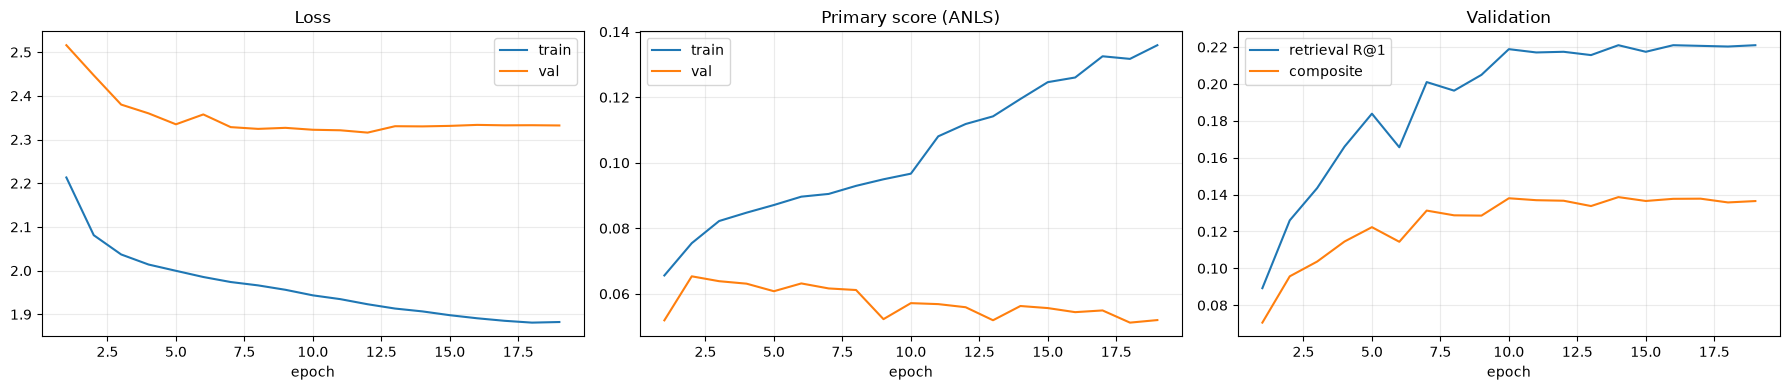

,best_epoch,best_val_accuracy,best_retrieval_r1,overfit_gap,overfit
0,14,0.056283,0.220993,0.0839,False


In [11]:
history_frame=pd.DataFrame(history); best_row=history_frame.loc[history_frame["composite"].idxmax()]
last=history_frame.iloc[-1]; overfit_gap=float(last["train_accuracy"]-last["val_accuracy"])
overfit=bool(last["train_accuracy"]-last["val_accuracy"]>0.15 or last["val_accuracy"]<best_row["val_accuracy"]-0.02)
fig,axes=plt.subplots(1,3,figsize=(18,4))
axes[0].plot(history_frame.epoch,history_frame.train_loss,label="train"); axes[0].plot(history_frame.epoch,history_frame.val_loss,label="val"); axes[0].legend(); axes[0].set_title("Loss")
axes[1].plot(history_frame.epoch,history_frame.train_accuracy,label="train"); axes[1].plot(history_frame.epoch,history_frame.val_accuracy,label="val"); axes[1].legend(); axes[1].set_title("Primary score (ANLS)")
axes[2].plot(history_frame.epoch,history_frame.val_retrieval_r1,label="retrieval R@1"); axes[2].plot(history_frame.epoch,history_frame.composite,label="composite"); axes[2].legend(); axes[2].set_title("Validation")
for axis in axes: axis.grid(alpha=.25); axis.set_xlabel("epoch")
plt.tight_layout(); plt.show()
display(pd.DataFrame([{"best_epoch":int(best_row.epoch),"best_val_accuracy":best_row.val_accuracy,
    "best_retrieval_r1":best_row.val_retrieval_r1,"overfit_gap":overfit_gap,"overfit":overfit}]))

## Test лучшего checkpoint и prediction

In [12]:
best_state=torch.load(RUN_DIR/"checkpoint_best.pt",map_location=DEVICE,weights_only=False); model.load_state_dict(best_state["model"])
test_metrics=evaluate_loader(model,test_loader,"test best checkpoint")
finished_all_epochs = len(history) == EPOCHS
metrics={"status":"completed_full" if finished_all_epochs else "completed_early_stopped","full_training_was_run":True,"dataset":"infographicvqa",
 "architecture":"sam2_dinov2_regularized_sparse_learned_graph","seed":SEED,"epochs_requested":EPOCHS,
 "epochs_completed":len(history),"best_epoch":int(best_state["epoch"]),"validation":best_state["metrics"],
 "test":test_metrics,"overfit_gap":overfit_gap,"overfit":overfit,
 "graph":{"predefined_edges":0,"learned_top_k":LEARNED_TOP_K,"question_conditioning":"second layer only"},
 "regularization":{"dropout":ATTENTION_DROPOUT,"weight_decay":WEIGHT_DECAY,"label_smoothing":LABEL_SMOOTHING,
 "ocr_node_dropout":OCR_NODE_DROPOUT,"sam_node_dropout":SAM_NODE_DROPOUT,"sparsity_coefficient":SPARSITY_COEFFICIENT,"hub_coefficient":HUB_COEFFICIENT}}
save_json(RUN_DIR/"metrics.json",metrics); save_json(RUN_DIR/"predictions.json",test_metrics.pop("predictions")); display(pd.DataFrame([{key:value for key,value in test_metrics.items() if key != "predictions"}]))

test best checkpoint:   0%|          | 0/103 [00:00<?, ?it/s]

test best checkpoint:   1%|          | 1/103 [00:00<00:24,  4.08it/s]

test best checkpoint:   2%|▏         | 2/103 [00:00<00:24,  4.13it/s]

test best checkpoint:   3%|▎         | 3/103 [00:00<00:25,  3.93it/s]

test best checkpoint:   4%|▍         | 4/103 [00:00<00:22,  4.31it/s]

...

test best checkpoint:  97%|█████████▋| 100/103 [00:29<00:00,  3.34it/s]

test best checkpoint:  98%|█████████▊| 101/103 [00:29<00:00,  3.52it/s]

test best checkpoint:  99%|█████████▉| 102/103 [00:30<00:00,  3.62it/s]

test best checkpoint: 100%|██████████| 103/103 [00:30<00:00,  4.40it/s]

,loss,accuracy,macro_f1,exact_match,retrieval_recall_at_1,retrieval_recall_at_5,retrieval_mrr
0,2.445556,0.0,0.0,0.0,0.199818,0.245438,0.235044


In [13]:
@torch.no_grad()
def predict_one(row):
    batch = collate_questions([row]); candidate_texts = batch["candidate_texts"][0]; batch = move_batch(batch); model.eval()
    result = model(batch["nodes"], batch["mask"], batch["questions"], batch["options"], batch["option_mask"])
    probabilities = result["vqa_logits"].softmax(1)[0, :len(candidate_texts)].cpu(); index = int(probabilities.argmax())
    return {"question": row["question"], "candidates": candidate_texts, "gold": row.get("answers", []),
            "prediction": candidate_texts[index], "probabilities": probabilities.tolist()}, result["attention"][:, 0].cpu(), batch

prediction, learned_attention, prediction_batch = predict_one(sample)
display(pd.DataFrame({"candidate": prediction["candidates"], "probability": prediction["probabilities"]}).sort_values("probability", ascending=False).head(15))
print("prediction:", prediction["prediction"], "| gold:", prediction["gold"], "| ANLS:", anls(prediction["prediction"], prediction["gold"]))


,candidate,probability
14,Sans-serif,0.031716
35,typewriter,0.030218
2,SANS,0.030138
48,Sans,0.030138
0,SERIF,0.028636
49,serif,0.028636
44,Serif,0.028636
4,UNAS,0.028101
38,"“serifs""",0.027448
66,SERIF ..,0.025803


prediction: Sans-serif | gold: ['serif fonts'] | ANLS: 0.0


## Визуализация графа, который построил Transformer

Для показа берётся среднее attention по головам последнего слоя. Для каждого узла отображаются пять наиболее
сильных связей. Это постобработка обученного attention, а не входной KNN-граф.

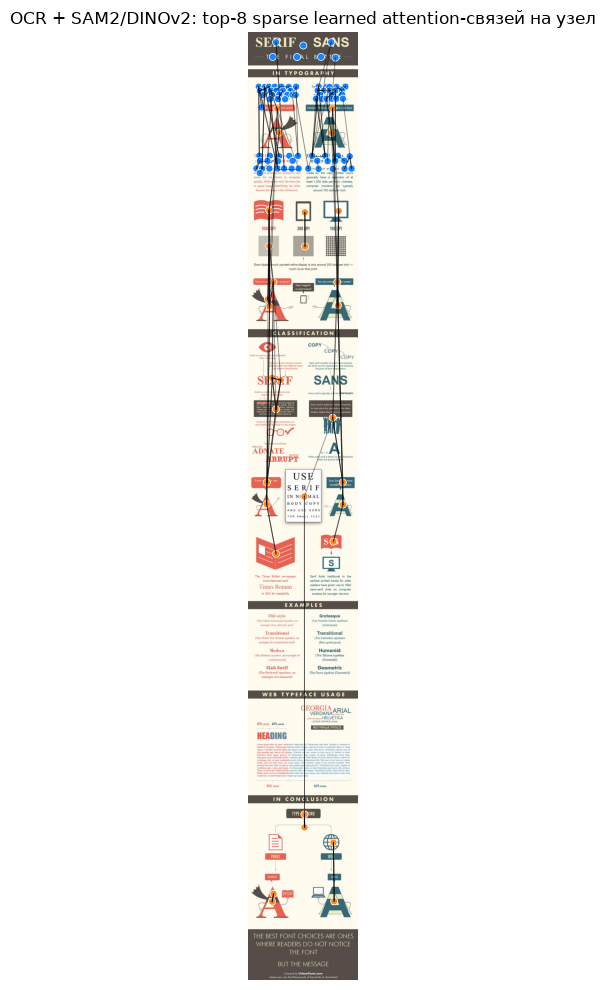

,source,target,attention
0,111,93,0.252799
1,93,111,0.235873
2,101,94,0.206206
3,106,108,0.189733
4,108,106,0.186508
5,94,101,0.182189
6,88,86,0.155206
7,110,103,0.143832
8,91,108,0.140275
9,83,103,0.139688


In [14]:
def visualize_learned_graph(row: dict, attention_layers: torch.Tensor, batch: dict, top_k: int = LEARNED_TOP_K):
    image = Image.open(row["image_path"]).convert("RGB")
    width, height = image.size
    count = int(batch["mask"][0].sum().item())
    features = batch["nodes"][0, :count].detach().cpu()
    centers = features[:, VISUAL_DIM:VISUAL_DIM + 2].numpy()
    types = features[:, -1].numpy()
    attention = attention_layers[-1].mean(dim=0)[:count, :count].numpy()
    np.fill_diagonal(attention, -np.inf)

    edges = set()
    for source in range(count):
        for target in np.argpartition(attention[source], -min(top_k, count - 1))[-min(top_k, count - 1):]:
            edges.add((source, int(target), float(attention[source, target])))
    strongest = sorted(edges, key=lambda value: value[2], reverse=True)[: min(160, len(edges))]

    fig, axis = plt.subplots(figsize=(10, 10))
    axis.imshow(image)
    for source, target, weight in strongest:
        x1, y1 = centers[source] * [width, height]
        x2, y2 = centers[target] * [width, height]
        axis.plot([x1, x2], [y1, y2], color="black", alpha=min(.75, .08 + weight * 4), linewidth=.7)
    colors = np.where(types > .5, "#1683ff", "#ff8a1f")
    axis.scatter(centers[:, 0] * width, centers[:, 1] * height, c=colors, s=26, edgecolors="white", linewidths=.5)
    axis.set_title("OCR + SAM2/DINOv2: top-8 sparse learned attention-связей на узел")
    axis.axis("off")
    plt.tight_layout(); plt.show()
    return pd.DataFrame(strongest, columns=["source", "target", "attention"]).head(20)


strongest_edges = visualize_learned_graph(sample, learned_attention, prediction_batch)
display(strongest_edges)


In [15]:
final_table = pd.DataFrame([{
    "dataset": "infographicvqa", "architecture": "sam2_dinov2_regularized_sparse_learned_graph", "predefined_edges": 0,
    "epochs": len(history), "best_epoch": metrics["best_epoch"], "validation_anls": metrics["validation"]["val_accuracy"],
    "test_anls": metrics["test"]["accuracy"], "test_exact_match": metrics["test"]["exact_match"],
    "test_token_f1": metrics["test"]["macro_f1"], "test_retrieval_r1": metrics["test"]["retrieval_recall_at_1"],
    "overfit": metrics["overfit"], "status": metrics["status"], "full_training_was_run": metrics["full_training_was_run"],
}])
display(final_table)
print(metrics["status"])


,dataset,architecture,predefined_edges,epochs,best_epoch,validation_anls,test_anls,test_exact_match,test_token_f1,test_retrieval_r1,overfit,status,full_training_was_run
0,infographicvqa,sam2_dinov2_regularized_sparse_learned_graph,0,19,14,0.056283,0.0,0.0,0.0,0.199818,False,completed_early_stopped,True


completed_early_stopped
